<div class="alert alert-block alert-success">
  <h3><center>MSDS-462: Computer Vision</center></h3>
  <h2><center>Brain Tumor Classification with Human-Readable MRI Explanations Using Deep Learning</center></h2>
  <h3><center>Data Analysis</center></h3>
</div>

<div class="alert alert-block alert-info">
    <h2>Import Dependency</h2>
</div>

In [1]:
# ============================================================
# 1. Imports
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm

sns.set(style="whitegrid")

/opt/anaconda3/lib/python3.12/site-packages/seaborn/_statistics.py:32: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.4.2)
  from scipy.stats import gaussian_kde


<div class="alert alert-block alert-info">
    <h2>Define the CNN</h2>
    <p>Create a Python class for your network that inherits from torch.nn.Module. Define a simple architecture inside it (e.g., two convolutional layers, each followed by a pooling layer, and two fully-connected layers at the end).</p>
</div>

In [2]:
# Update this path to where the dataset is stored

DATA_DIR = "mri_dataset"

TRAIN_DIR = os.path.join(DATA_DIR, "Training")
TEST_DIR = os.path.join(DATA_DIR, "Testing")

classes = os.listdir(TRAIN_DIR)

print("Classes:", classes)

Classes: ['pituitary', 'notumor', 'glioma', 'meningioma']


<div class="alert alert-block alert-info">
    <h2>Count Images per Class</h2>
</div>

In [3]:
def count_images(directory):
    
    class_counts = {}
    
    for cls in os.listdir(directory):
        path = os.path.join(directory, cls)
        class_counts[cls] = len(os.listdir(path))
    
    return pd.DataFrame.from_dict(class_counts, orient='index', columns=['count'])


train_counts = count_images(TRAIN_DIR)
test_counts = count_images(TEST_DIR)

print("Training distribution")
display(train_counts)

print("Testing distribution")
display(test_counts)

Training distribution


,count
pituitary,1400
notumor,1400
glioma,1400
meningioma,1400


Testing distribution


,count
pituitary,400
notumor,400
glioma,400
meningioma,400


<div class="alert alert-block alert-info">
    <h2>Class Distribution</h2>
</div>

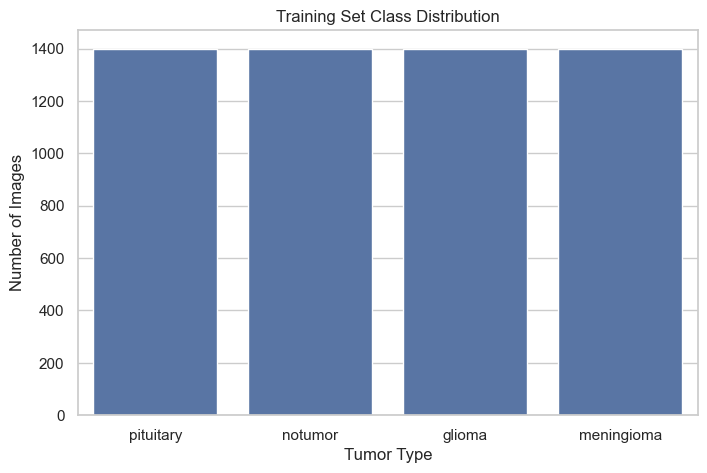

In [4]:
plt.figure(figsize=(8,5))
sns.barplot(x=train_counts.index, y=train_counts['count'])
plt.title("Training Set Class Distribution")
plt.ylabel("Number of Images")
plt.xlabel("Tumor Type")
plt.show()

<div class="alert alert-block alert-info">
    <h2>One sample image from Each Class</h2>
</div>

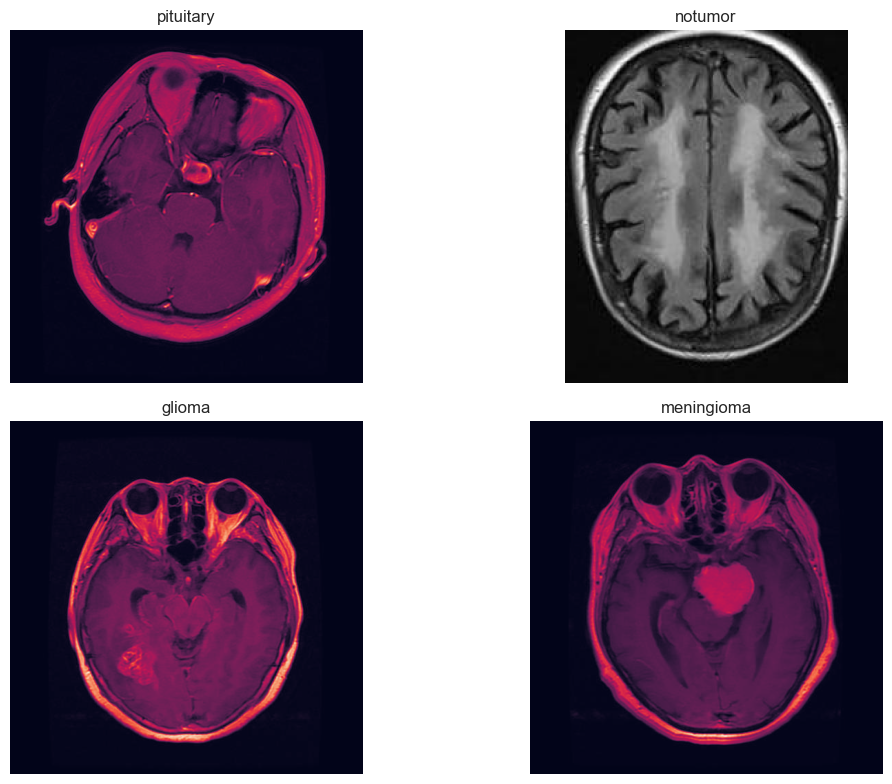

In [5]:
plt.figure(figsize=(12,8))

for i, cls in enumerate(classes):
    
    img_path = os.listdir(os.path.join(TRAIN_DIR, cls))[0]
    img = Image.open(os.path.join(TRAIN_DIR, cls, img_path))
    
    plt.subplot(2,2,i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")

plt.tight_layout()
plt.show()

<div class="alert alert-block alert-info">
    <h2>Image Size Analysis</h2>
</div>

In [6]:
sizes = []

for cls in classes:
    folder = os.path.join(TRAIN_DIR, cls)
    for img_name in tqdm(os.listdir(folder)):
        img = Image.open(os.path.join(folder, img_name))
        sizes.append(img.size)

sizes = pd.DataFrame(sizes, columns=["width","height"])
sizes.describe()

100%|██████████| 1400/1400 [00:00<00:00, 6436.48it/s]


,width,height
count,5600.000000,5600.000000
mean,458.513750,462.262857
std,129.619399,123.617483
min,150.000000,168.000000
25%,512.000000,512.000000
50%,512.000000,512.000000
75%,512.000000,512.000000
max,1375.000000,1446.000000


<div class="alert alert-block alert-info">
    <h2>Image Size Distribution</h2>
</div>

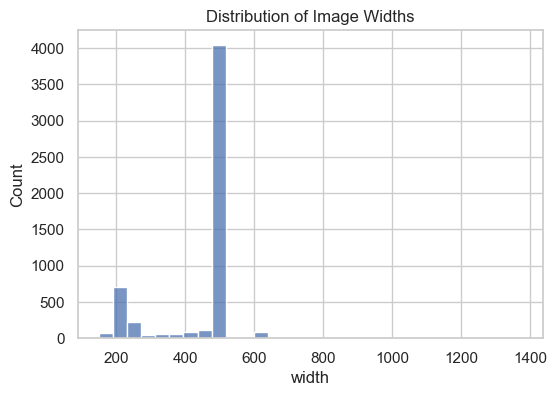

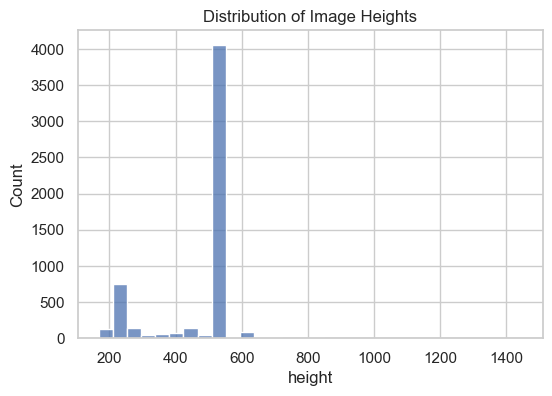

In [10]:
plt.figure(figsize=(6,4))
sns.histplot(sizes["width"], bins=30)
plt.title("Distribution of Image Widths")
plt.show()


plt.figure(figsize=(6,4))
sns.histplot(sizes["height"], bins=30)
plt.title("Distribution of Image Heights")
plt.show()

<div class="alert alert-block alert-info">
    <h2>Pixel Intensity Distribution</h2>
</div>

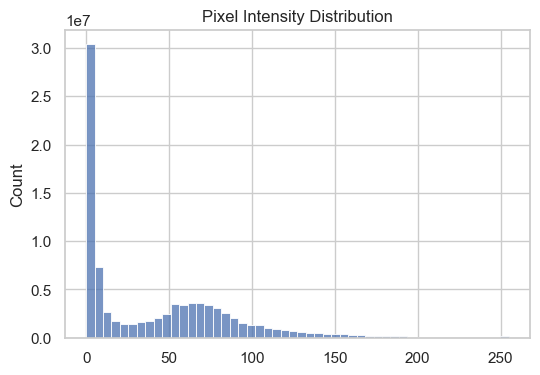

In [9]:
pixels = []

for cls in classes:
    folder = os.path.join(TRAIN_DIR, cls)
    for img_name in os.listdir(folder)[:100]:
        img = np.array(Image.open(os.path.join(folder, img_name)).convert("L"))
        pixels.extend(img.flatten())

pixels = np.array(pixels)
plt.figure(figsize=(6,4))
sns.histplot(pixels, bins=50)
plt.title("Pixel Intensity Distribution")
plt.show()

<div class="alert alert-block alert-info">
    <h2>Mean Image per Class</h2>
</div>

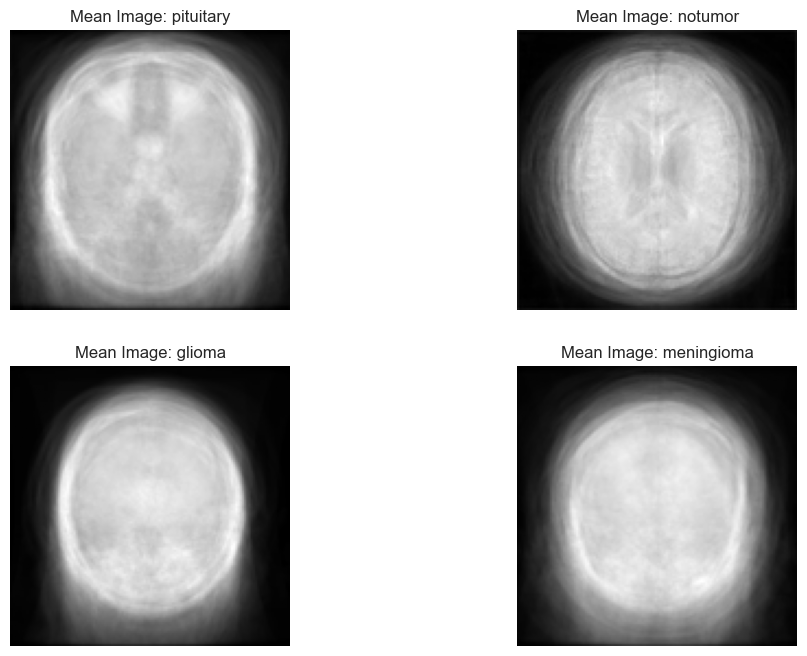

In [11]:
def mean_image(class_name):
    folder = os.path.join(TRAIN_DIR, class_name)
    images = []
    for img_name in os.listdir(folder)[:200]:
        img = Image.open(os.path.join(folder, img_name)).resize((128,128))
        img = np.array(img.convert("L"))
        images.append(img)
    return np.mean(images, axis=0)


plt.figure(figsize=(12,8))
for i, cls in enumerate(classes):
    mean_img = mean_image(cls)
    plt.subplot(2,2,i+1)
    plt.imshow(mean_img, cmap="gray")
    plt.title(f"Mean Image: {cls}")
    plt.axis("off")
plt.show()

<div class="alert alert-block alert-info">
    <h2>Train vs Test Comparison</h2>
</div>

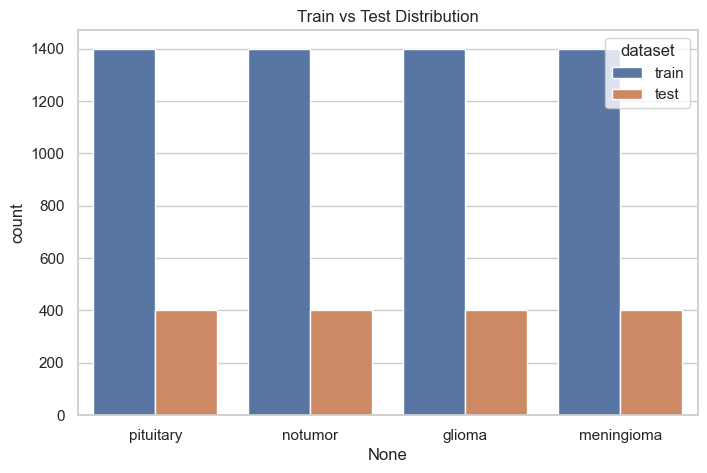

In [12]:
df = pd.concat([
    train_counts.assign(dataset="train"),
    test_counts.assign(dataset="test")
])

plt.figure(figsize=(8,5))
sns.barplot(data=df, x=df.index, y="count", hue="dataset")
plt.title("Train vs Test Distribution")
plt.show()

<div class="alert alert-block alert-info">
    <h2>Statistics</h2>
</div>

In [13]:
print("Total Training Images:", train_counts["count"].sum())
print("Total Testing Images:", test_counts["count"].sum())
print("Number of Classes:", len(classes))

Total Training Images: 5600
Total Testing Images: 1600
Number of Classes: 4
